In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, MinMaxScaler, TargetEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from lightgbm import LGBMClassifier
from helper import *
from plots import *
import random
import seaborn as sns


In [2]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [3]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [4]:
data = pd.read_csv('adult.csv')

In [5]:
df_preprocessed = data.copy()
df_preprocessed = df_preprocessed.drop(['fnlwgt', 'educational-num'], axis=1)
df_preprocessed = df_preprocessed.replace('?', np.nan)
df_preprocessed['income'] = np.where(df_preprocessed['income'] == '>50K', 1, 0)
df_preprocessed['Own-child'] = (df_preprocessed['relationship'] == 'Own-child').astype(int)

df_preprocessed.head()

,age,workclass,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,Own-child
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,1
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,0
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,0
4,18,NaN,Some-college,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,1


In [6]:
education_map = {
    'Preschool': 'School',
    '1st-4th':   'School',
    '5th-6th':   'School',
    '7th-8th':   'School',
    '9th':       'School',
    '10th':      'School',
    '11th':      'School',
    '12th':      'School',

    'HS-grad':      'HS-grad',
    'Some-college': 'Some-college',

    'Assoc-voc':  'Assoc',
    'Assoc-acdm': 'Assoc',

    'Bachelors':   'Bachelors',

    'Masters':     'Post-grad',
    'Prof-school': 'Post-grad',
    'Doctorate':   'Post-grad',
}

country_map = {
    'United-States': 'US',
    'Canada': 'Anglo',
    'England': 'Anglo',
    'Australia': 'Anglo',
    'Ireland': 'Anglo',
    'Scotland': 'Anglo',

    'Mexico': 'LatAm',
    'Puerto-Rico': 'LatAm',
    'Cuba': 'LatAm',
    'Jamaica': 'LatAm',
    'Dominican-Republic': 'LatAm',
    'El-Salvador': 'LatAm',
    'Guatemala': 'LatAm',
    'Columbia': 'LatAm',
    'Haiti': 'LatAm',
    'Honduras': 'LatAm',
    'Nicaragua': 'LatAm',
    'Peru': 'LatAm',
    'Trinadad&Tobago': 'LatAm',
    'Ecuador': 'LatAm',

    'Germany': 'Europe',
    'Italy': 'Europe',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'France': 'Europe',
    'Greece': 'Europe',
    'Holand-Netherlands': 'Europe',
    'Hungary': 'Europe',
    'Yugoslavia': 'Europe',

    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Philippines': 'Asia',
    'Vietnam': 'Asia',
    'Taiwan': 'Asia',
    'Iran': 'Asia',
    'Thailand': 'Asia',
    'Hong': 'Asia',
    'Cambodia': 'Asia',
    'Laos': 'Asia',
}


marital_map = {
    'Married-civ-spouse':    'Married',
    'Married-AF-spouse':     'Married',

    'Married-spouse-absent': 'Married-absent',

    'Divorced':  'Was married',
    'Separated': 'Was married',
    'Widowed':   'Was married',

    'Never-married': 'Never married',
}


race_map = {
    'White':               'White',
    'Black':               'Black',
    'Asian-Pac-Islander':  'Asian',
    'Amer-Indian-Eskimo':  'Other',
    'Other':               'Other',
}

workclass_map = {
    'Private':          'Private',
    'Self-emp-inc':     'Entrepreneur',
    'Self-emp-not-inc': 'Self-emp',       
    'Federal-gov':      'Gov',
    'Local-gov':        'Gov',
    'State-gov':        'Gov',
    'Without-pay':      'No-income',
    'Never-worked':     'No-income',
}

occupation_map = {
    'Prof-specialty':  'High white-collar',
    'Exec-managerial': 'High white-collar',

    'Adm-clerical':    'Low white-collar',
    'Tech-support':    'Low white-collar',

    'Sales':           'Sales',

    'Other-service':   'Service',
    'Protective-serv': 'Service',
    'Priv-house-serv': 'Service',

    'Craft-repair':      'Blue-collar',
    'Machine-op-inspct': 'Blue-collar',
    'Transport-moving':  'Blue-collar',
    'Handlers-cleaners': 'Blue-collar',

    'Farming-fishing': 'Other',
    'Armed-Forces':    'Other',
}




In [7]:
df_preprocessed['education_group'] = df_preprocessed['education'].map(education_map)
df_preprocessed['country_group'] = df_preprocessed['native-country'].map(country_map)
df_preprocessed['race_group'] = df_preprocessed['race'].map(race_map)
df_preprocessed['occupation_group'] = df_preprocessed['occupation'].map(occupation_map)
df_preprocessed['marital_group'] = df_preprocessed['marital-status'].map(marital_map)
df_preprocessed['workclass_group'] = df_preprocessed['workclass'].map(workclass_map)

df_preprocessed = df_preprocessed.drop(['workclass', 'marital-status', 'race', 'occupation', 'native-country', 'education', 'relationship'], axis=1)
df_preprocessed.head()

,age,gender,capital-gain,capital-loss,hours-per-week,income,Own-child,education_group,country_group,race_group,occupation_group,marital_group,workclass_group
0,25,Male,0,0,40,0,1,School,US,Black,Blue-collar,Never married,Private
1,38,Male,0,0,50,0,0,HS-grad,US,White,Other,Married,Private
2,28,Male,0,0,40,1,0,Assoc,US,White,Service,Married,Gov
3,44,Male,7688,0,40,1,0,Some-college,US,Black,Blue-collar,Married,Private
4,18,Female,0,0,30,0,1,Some-college,US,White,NaN,Never married,NaN


In [8]:
X, y = divide_data(df_preprocessed, 'income')

In [9]:
categorical_cols_onehot = ['gender', 'country_group', 'marital_group', 'race_group', 'workclass_group', 'occupation_group']
categorical_cols_ordered = ['education_group']
category_orders = [
    ['School', 'HS-grad', 'Some-college', 'Assoc', 'Bachelors', 'Post-grad'], # education_group
]
most_frequent_cat_cols = ['workclass_group', 'occupation_group', 'country_group']

preprocessor = Pipeline([
    ('nan_remover', ColumnTransformer(
        [
            ('most_frequent_cat', SimpleImputer(strategy='most_frequent'), most_frequent_cat_cols),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )),
    ('transformations', ColumnTransformer(
        [('ordinal', OrdinalEncoder(
            categories=category_orders, 
            handle_unknown='use_encoded_value',
            unknown_value=-1,),
            categorical_cols_ordered),

         ('onehot', OneHotEncoder(
             drop='first',
             handle_unknown='ignore',
             sparse_output=False, 
         ), 
            categorical_cols_onehot)],
        remainder='passthrough',
        verbose_feature_names_out=False
    ))
])
preprocessor.set_output(transform="pandas")

,steps,"[('nan_remover', ...), ('transformations', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('most_frequent_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"

In [10]:
models = [
    ('LogisticRegression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=10)),
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED)),
    ('LGBMClassifier', LGBMClassifier(random_state=SEED))
]

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003499 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 395
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

<Figure size 1500x600 with 0 Axes>

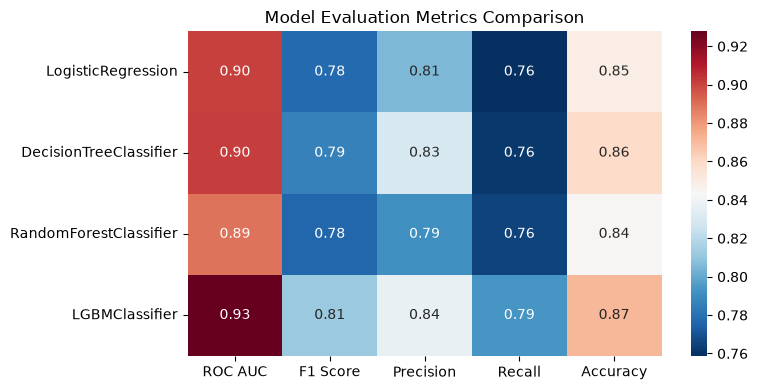

In [12]:
initial_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

# 2. Преобразование данных и feature engineering

1. Бины для часов работы
2. Хитрые преобразования с доходом???
4. Взаимодействие фичей??? Но каких?

## Бины для возраста человека

### Без удаления

In [69]:
X_age_bins = X.copy()

In [70]:
bins=[0, 25, 35, 45, 55, 65, 100]
labels = np.arange(len(bins)-1)

X_age_bins['age_bins'] = pd.cut(X_age_bins['age'], bins=bins, labels=labels)

In [71]:
X_age_bins

,age,gender,capital-gain,capital-loss,hours-per-week,Own-child,education_group,country_group,race_group,occupation_group,marital_group,workclass_group,age_bins
0,25,Male,0,0,40,1,School,US,Black,Blue-collar,Never married,Private,0
1,38,Male,0,0,50,0,HS-grad,US,White,Other,Married,Private,2
2,28,Male,0,0,40,0,Assoc,US,White,Service,Married,Gov,1
3,44,Male,7688,0,40,0,Some-college,US,Black,Blue-collar,Married,Private,2
4,18,Female,0,0,30,1,Some-college,US,White,NaN,Never married,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Female,0,0,38,0,Assoc,US,White,Low white-collar,Married,Private,1
48838,40,Male,0,0,40,0,HS-grad,US,White,Blue-collar,Married,Private,2
48839,58,Female,0,0,40,0,HS-grad,US,White,Low white-collar,Was married,Private,4
48840,22,Male,0,0,20,1,HS-grad,US,White,Low white-collar,Never married,Private,0


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002668 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

<Figure size 1500x600 with 0 Axes>

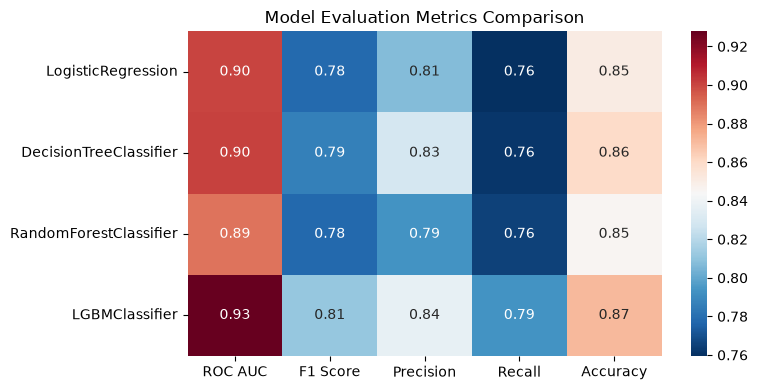

In [ ]:
age_binning_metrics = train_evaluate_models_cv(
    models=models,
    X=X_age_bins,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.000143  0.000954   0.001325  0.000764  0.000717
 DecisionTreeClassifier -0.000339 -0.000006  -0.000073  0.000016 -0.000020
 RandomForestClassifier -0.000249  0.000919   0.002192  0.000153  0.001126
 LGBMClassifier          0.000050 -0.000492  -0.000495 -0.000479 -0.000328)

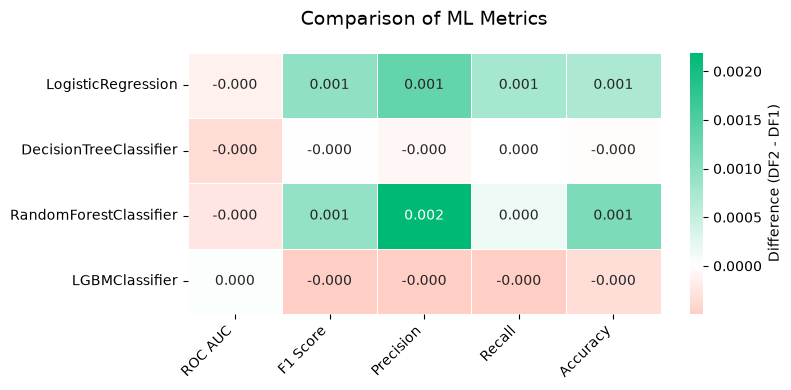

In [63]:
compare_metrics_heatmap(initial_metrics, age_binning_metrics)

### С удалением

In [73]:
X_age_bins_del = X.copy()

In [74]:
bins=[0, 25, 35, 45, 55, 65, 100]
labels = np.arange(len(bins)-1)

X_age_bins_del['age'] = pd.cut(X_age_bins_del['age'], bins=bins, labels=labels)

In [75]:
X_age_bins_del

,age,gender,capital-gain,capital-loss,hours-per-week,Own-child,education_group,country_group,race_group,occupation_group,marital_group,workclass_group
0,0,Male,0,0,40,1,School,US,Black,Blue-collar,Never married,Private
1,2,Male,0,0,50,0,HS-grad,US,White,Other,Married,Private
2,1,Male,0,0,40,0,Assoc,US,White,Service,Married,Gov
3,2,Male,7688,0,40,0,Some-college,US,Black,Blue-collar,Married,Private
4,0,Female,0,0,30,1,Some-college,US,White,NaN,Never married,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,1,Female,0,0,38,0,Assoc,US,White,Low white-collar,Married,Private
48838,2,Male,0,0,40,0,HS-grad,US,White,Blue-collar,Married,Private
48839,4,Female,0,0,40,0,HS-grad,US,White,Low white-collar,Was married,Private
48840,0,Male,0,0,20,1,HS-grad,US,White,Low white-collar,Never married,Private


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 328
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

<Figure size 1500x600 with 0 Axes>

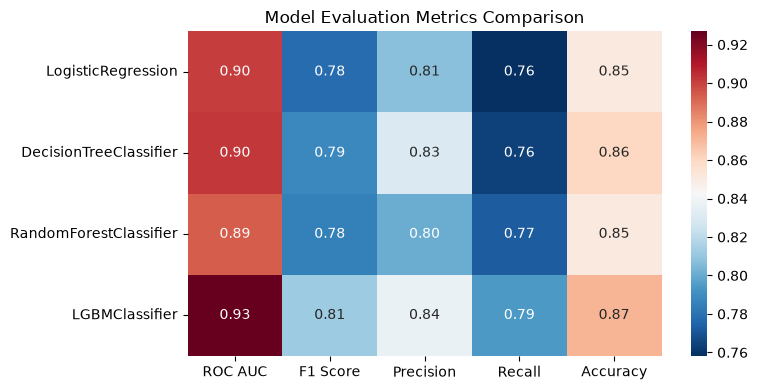

In [76]:
age_binning_del_metrics = train_evaluate_models_cv(
    models=models,
    X=X_age_bins_del,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.000093  0.000262   0.002034 -0.000555  0.000717
 DecisionTreeClassifier  0.000458  0.001703   0.000512  0.002006  0.000778
 RandomForestClassifier  0.004060  0.008243   0.009517  0.007327  0.006060
 LGBMClassifier         -0.000871  0.000270  -0.000211  0.000525  0.000041)

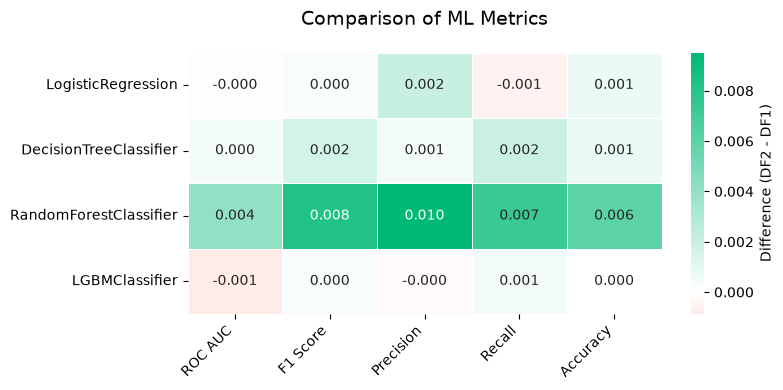

In [77]:
compare_metrics_heatmap(initial_metrics, age_binning_del_metrics)

## Бины для часов работы

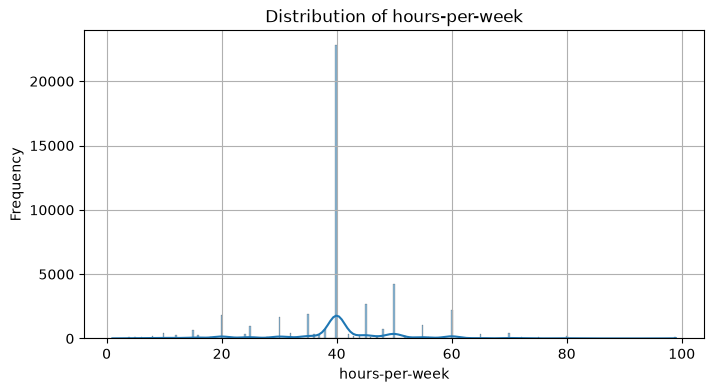

In [80]:
plot_hist_numeric(data, 'hours-per-week')

### без удаления

In [82]:
X_hours_bins = X.copy()

In [104]:
bins = np.arange(0, 101, 10)
# bins = [0, 15, 30, 60, 75, 100]
labels = np.arange(len(bins) - 1)

X_hours_bins['hours_bins'] = pd.cut(X_hours_bins['hours-per-week'], bins=bins, labels=labels)

In [105]:
X_hours_bins

,age,gender,capital-gain,capital-loss,hours-per-week,Own-child,education_group,country_group,race_group,occupation_group,marital_group,workclass_group,hours_bins
0,25,Male,0,0,40,1,School,US,Black,Blue-collar,Never married,Private,3
1,38,Male,0,0,50,0,HS-grad,US,White,Other,Married,Private,4
2,28,Male,0,0,40,0,Assoc,US,White,Service,Married,Gov,3
3,44,Male,7688,0,40,0,Some-college,US,Black,Blue-collar,Married,Private,3
4,18,Female,0,0,30,1,Some-college,US,White,NaN,Never married,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Female,0,0,38,0,Assoc,US,White,Low white-collar,Married,Private,3
48838,40,Male,0,0,40,0,HS-grad,US,White,Blue-collar,Married,Private,3
48839,58,Female,0,0,40,0,HS-grad,US,White,Low white-collar,Was married,Private,3
48840,22,Male,0,0,20,1,HS-grad,US,White,Low white-collar,Never married,Private,1


интересно глянуть зависимость

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001650 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 405
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002057 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 407
[LightGBM] [Info] N

<Figure size 1500x600 with 0 Axes>

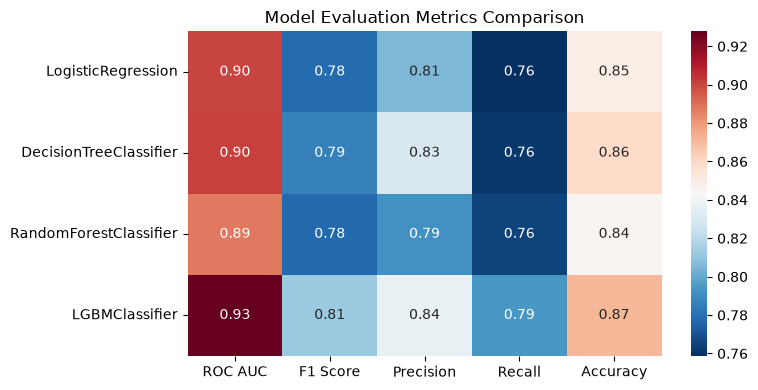

In [106]:
hours_binning_metrics = train_evaluate_models_cv(
    models=models,
    X=X_hours_bins,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.000334 -0.000155  -0.000422 -0.000033 -0.000184
 DecisionTreeClassifier -0.000385  0.000007  -0.000105  0.000045 -0.000020
 RandomForestClassifier -0.001476  0.000363   0.000920  0.000016  0.000471
 LGBMClassifier          0.000009  0.000154  -0.000304  0.000397 -0.000020)

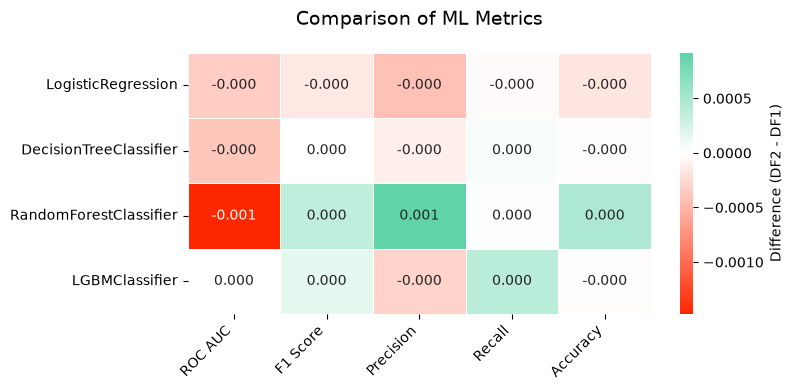

In [107]:
compare_metrics_heatmap(initial_metrics, hours_binning_metrics)

### with del

In [96]:
X_hours_bins_del = X.copy()

bins = np.arange(0, 101, 10)
labels = np.arange(len(bins) - 1)

X_hours_bins_del['hours-per-week'] = pd.cut(X_hours_bins_del['hours-per-week'], bins=bins, labels=labels)

In [97]:
X_hours_bins_del

,age,gender,capital-gain,capital-loss,hours-per-week,Own-child,education_group,country_group,race_group,occupation_group,marital_group,workclass_group
0,25,Male,0,0,3,1,School,US,Black,Blue-collar,Never married,Private
1,38,Male,0,0,4,0,HS-grad,US,White,Other,Married,Private
2,28,Male,0,0,3,0,Assoc,US,White,Service,Married,Gov
3,44,Male,7688,0,3,0,Some-college,US,Black,Blue-collar,Married,Private
4,18,Female,0,0,2,1,Some-college,US,White,NaN,Never married,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Female,0,0,3,0,Assoc,US,White,Low white-collar,Married,Private
48838,40,Male,0,0,3,0,HS-grad,US,White,Blue-collar,Married,Private
48839,58,Female,0,0,3,0,HS-grad,US,White,Low white-collar,Was married,Private
48840,22,Male,0,0,1,1,HS-grad,US,White,Low white-collar,Never married,Private


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

<Figure size 1500x600 with 0 Axes>

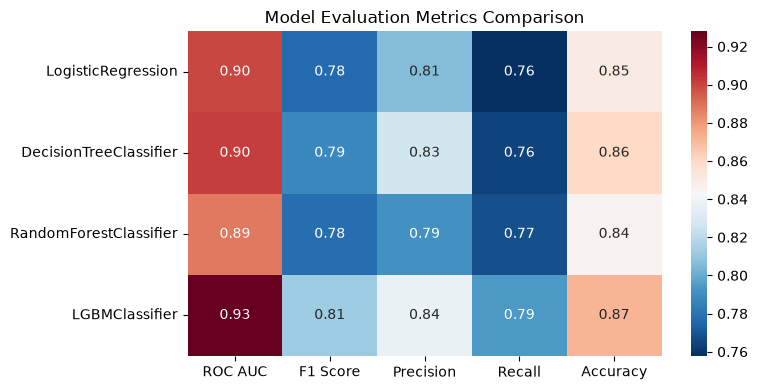

In [98]:
hours_binning_del_metrics = train_evaluate_models_cv(
    models=models,
    X=X_hours_bins_del,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.000987 -0.000404   0.000775 -0.000946  0.000123
 DecisionTreeClassifier  0.000447  0.001380  -0.002284  0.002670 -0.000041
 RandomForestClassifier -0.001677  0.001877  -0.000074  0.003066  0.000471
 LGBMClassifier          0.000183  0.000485   0.000200  0.000631  0.000246)

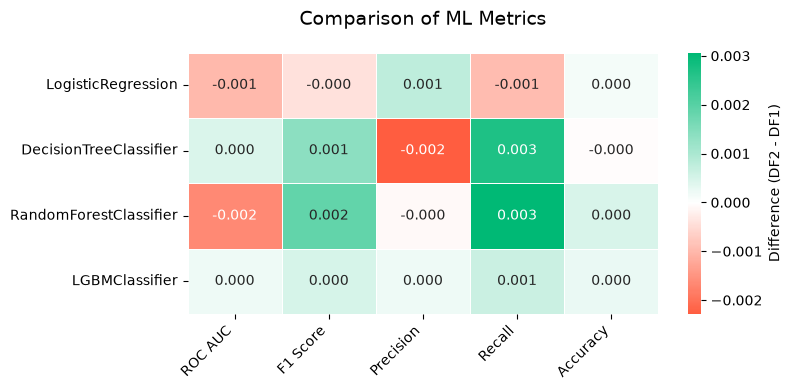

In [99]:
compare_metrics_heatmap(initial_metrics, hours_binning_del_metrics)

## Преобразования над capital gain

### Стандартизация

### без удаления

In [18]:
X_gain_loss_scaler = X.copy()

scaled_columns = ['capital-gain_scaled', 'capital-loss_scaled']
X_gain_loss_scaler[scaled_columns] = X_gain_loss_scaler[['capital-gain', 'capital-loss']]

scaler = StandardScaler()

X_gain_loss_scaler[scaled_columns] = scaler.fit_transform(X_gain_loss_scaler[scaled_columns])

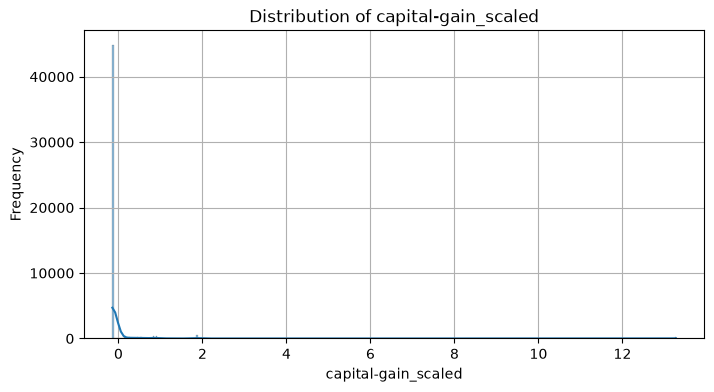

In [19]:
plot_hist_numeric(X_gain_loss_scaler, 'capital-gain_scaled')

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 582
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

<Figure size 1500x600 with 0 Axes>

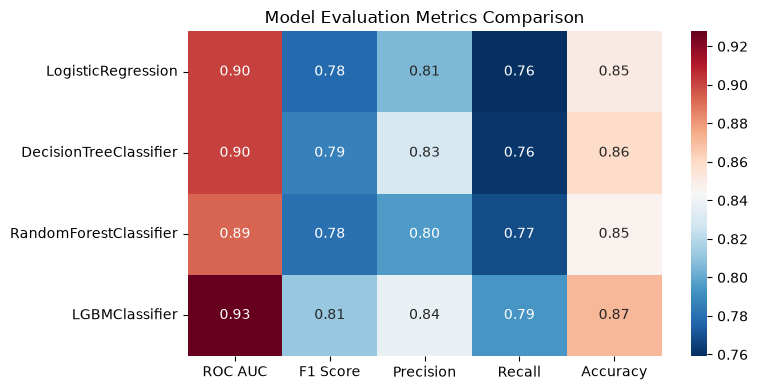

In [22]:
gain_loss_scaler_metrics = train_evaluate_models_cv(
    models=models,
    X=X_gain_loss_scaler,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score     Precision        Recall  \
 LogisticRegression      0.000021  0.000486  3.980170e-04  5.109322e-04   
 DecisionTreeClassifier -0.000178 -0.000002  1.776598e-07 -1.830193e-08   
 RandomForestClassifier  0.002884  0.004004  4.618925e-03  3.580078e-03   
 LGBMClassifier          0.000000  0.000000  0.000000e+00  0.000000e+00   
 
                             Accuracy  
 LogisticRegression      2.866335e-04  
 DecisionTreeClassifier -2.095918e-09  
 RandomForestClassifier  2.948288e-03  
 LGBMClassifier          0.000000e+00  )

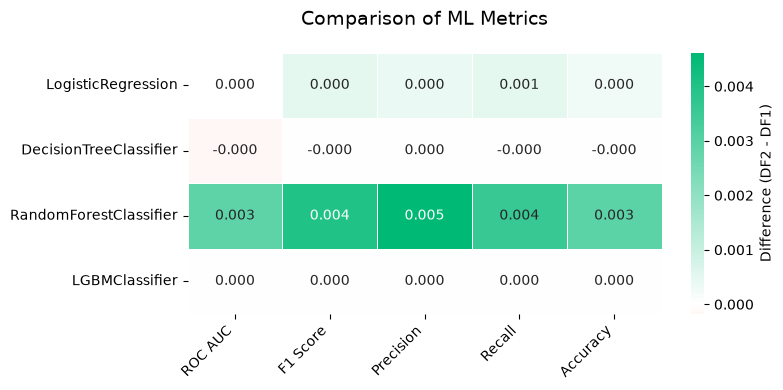

In [23]:
compare_metrics_heatmap(initial_metrics, gain_loss_scaler_metrics)

### c удалением

In [26]:
X_gain_loss_scaler_del = X.copy()

scaled_columns = ['capital-gain', 'capital-loss']
scaler = StandardScaler()

X_gain_loss_scaler_del[scaled_columns] = scaler.fit_transform(X_gain_loss_scaler_del[scaled_columns])

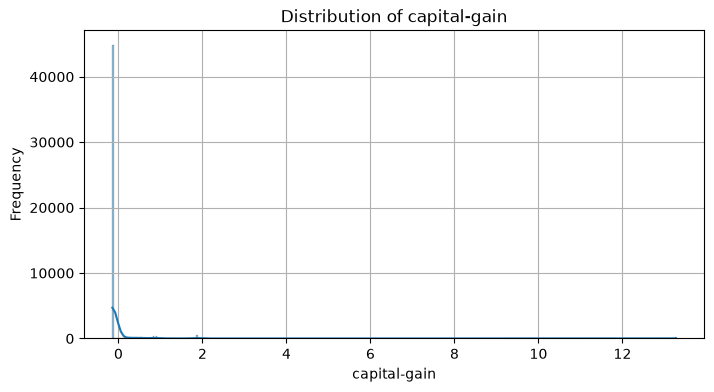

In [28]:
plot_hist_numeric(X_gain_loss_scaler_del, 'capital-gain')

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001921 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 397
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

<Figure size 1500x600 with 0 Axes>

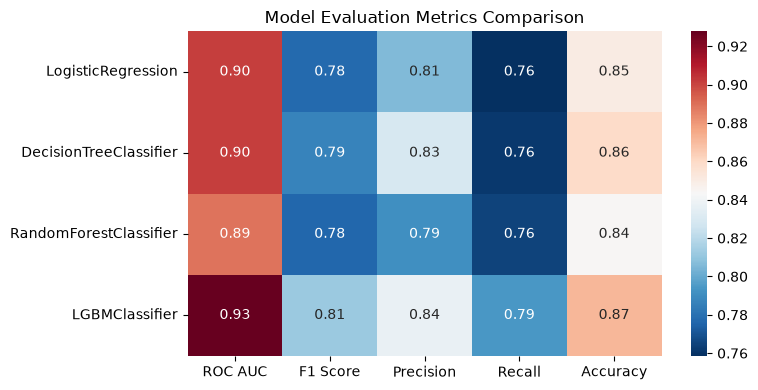

In [29]:
gain_loss_scaler_del_metrics = train_evaluate_models_cv(
    models=models,
    X=X_gain_loss_scaler_del,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                              ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression      7.159541e-04  0.000055   0.000509 -0.000172  0.000184
 DecisionTreeClassifier  0.000000e+00  0.000000   0.000000  0.000000  0.000000
 RandomForestClassifier  1.323842e-07  0.000000   0.000000  0.000000  0.000000
 LGBMClassifier          0.000000e+00  0.000000   0.000000  0.000000  0.000000)

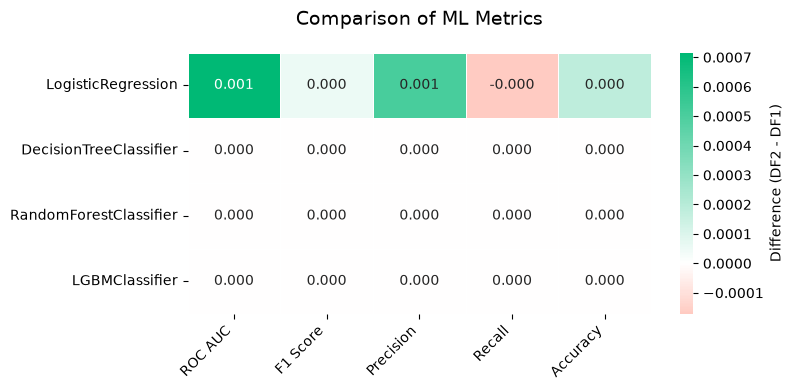

In [30]:
compare_metrics_heatmap(initial_metrics, gain_loss_scaler_del_metrics)

### flag

In [127]:
X_gain_loss_flag = X.copy()
X_gain_loss_flag['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)
X_gain_loss_flag['has_capital_loss'] = (X['capital-loss'] > 0).astype(int)

X_gain_loss_flag

,age,gender,capital-gain,capital-loss,hours-per-week,Own-child,education_group,country_group,race_group,occupation_group,marital_group,workclass_group,has_capital_gain,has_capital_loss
0,25,Male,0,0,40,1,School,US,Black,Blue-collar,Never married,Private,0,0
1,38,Male,0,0,50,0,HS-grad,US,White,Other,Married,Private,0,0
2,28,Male,0,0,40,0,Assoc,US,White,Service,Married,Gov,0,0
3,44,Male,7688,0,40,0,Some-college,US,Black,Blue-collar,Married,Private,1,0
4,18,Female,0,0,30,1,Some-college,US,White,NaN,Never married,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Female,0,0,38,0,Assoc,US,White,Low white-collar,Married,Private,0,0
48838,40,Male,0,0,40,0,HS-grad,US,White,Blue-collar,Married,Private,0,0
48839,58,Female,0,0,40,0,HS-grad,US,White,Low white-collar,Was married,Private,0,0
48840,22,Male,0,0,20,1,HS-grad,US,White,Low white-collar,Never married,Private,0,0


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 399
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

<Figure size 1500x600 with 0 Axes>

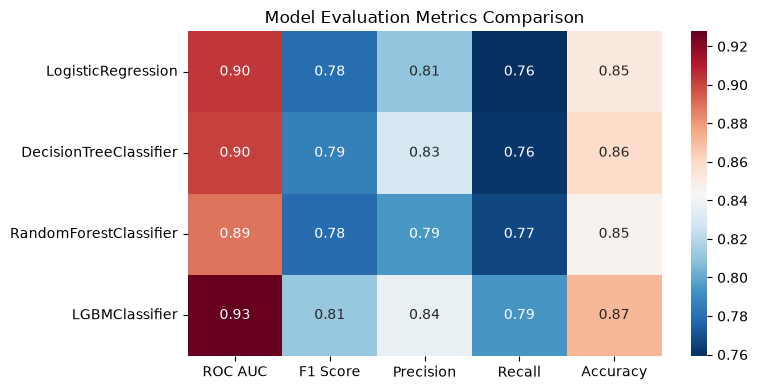

In [128]:
gain_loss_flag_metrics = train_evaluate_models_cv(
    models=models,
    X=X_gain_loss_flag,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression      0.003009  0.001917   0.004778  0.000549  0.002129
 DecisionTreeClassifier -0.000688 -0.000261  -0.000417 -0.000193 -0.000205
 RandomForestClassifier  0.000136  0.002347   0.002937  0.001960  0.001822
 LGBMClassifier         -0.000007 -0.000049  -0.000005 -0.000072 -0.000020)

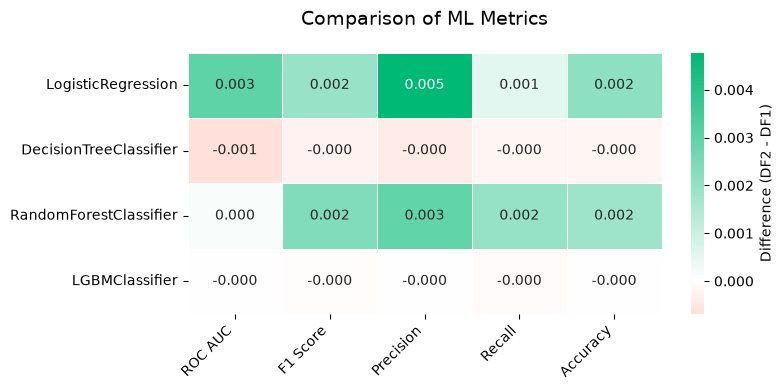

In [129]:
compare_metrics_heatmap(initial_metrics, gain_loss_flag_metrics)

## Работа с дисбалансом классов

### на уровне моделей

In [31]:
models_balanced = [
    ('LogisticRegression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear', class_weight='balanced')),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=10, class_weight='balanced')),
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED, class_weight='balanced')),
    ('LGBMClassifier', LGBMClassifier(random_state=SEED, class_weight='balanced'))
]

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 395
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

<Figure size 1500x600 with 0 Axes>

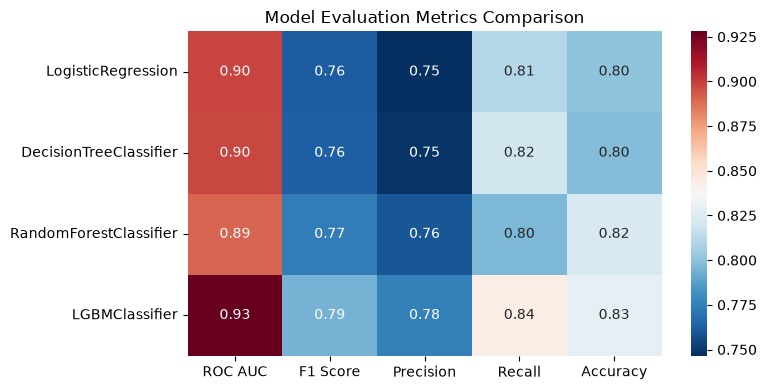

In [32]:
balanced_metrics = train_evaluate_models_cv(
    models=models_balanced,
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.002129 -0.015409  -0.059107  0.051874 -0.048995
 DecisionTreeClassifier -0.003741 -0.023790  -0.080551  0.058519 -0.061771
 RandomForestClassifier  0.000719 -0.002778  -0.031907  0.031404 -0.021600
 LGBMClassifier          0.000264 -0.017609  -0.061482  0.050615 -0.042566)

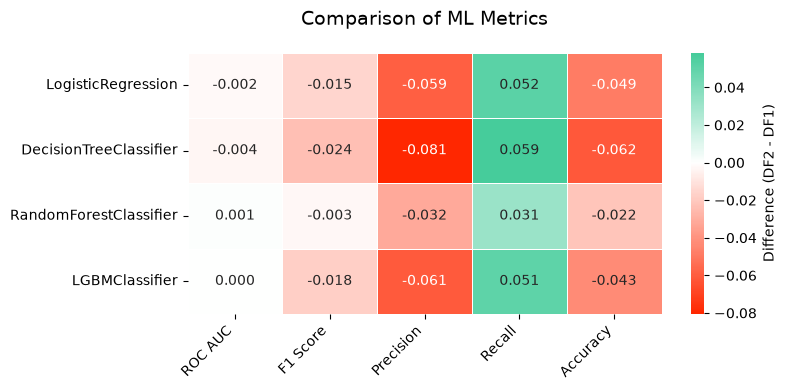

In [33]:
compare_metrics_heatmap(initial_metrics, balanced_metrics)

### SMOTE

In [34]:
preprocessor_smote = clone(preprocessor)

preprocessor_smote.steps.append(
    ('smote', SMOTE(random_state=SEED))
)

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 29724, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5122
[LightGBM] [Info] Number of data points in the train set: 59448, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 29724, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5115
[Light

<Figure size 1500x600 with 0 Axes>

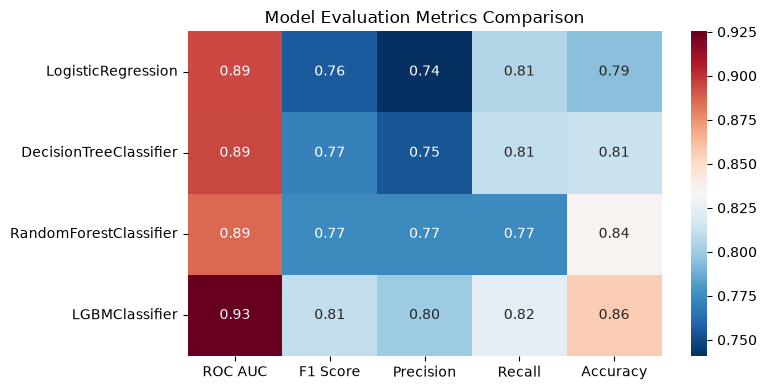

In [35]:
smote_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor_smote,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.007373 -0.021792  -0.064683  0.046277 -0.055055
 DecisionTreeClassifier -0.007167 -0.015739  -0.074939  0.048742 -0.047111
 RandomForestClassifier -0.003706 -0.002270  -0.017386  0.009518 -0.008988
 LGBMClassifier         -0.002509 -0.001538  -0.037235  0.029858 -0.015253)

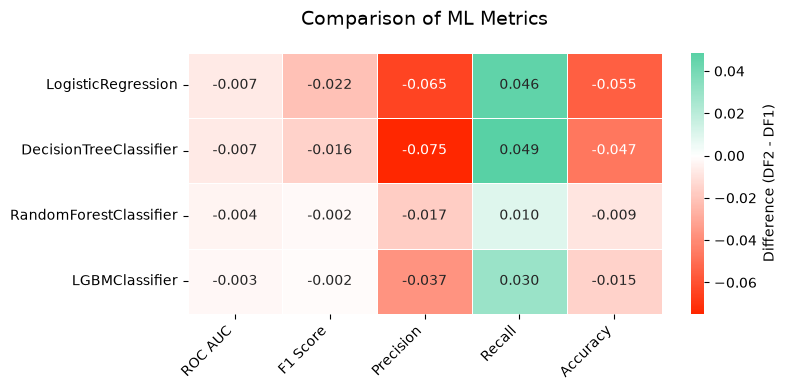

In [36]:
compare_metrics_heatmap(initial_metrics, smote_metrics)